## Load PDF Dataset

In [17]:
import os
from pathlib import Path
from langchain_community.document_loaders import PyPDFLoader

# Confguration
PDF_GEN_AI_BANKING = Path("../../Database/PDF/Generative AI and LLMs in Banking.pdf")
PDF_ML_APPLICATIONS = Path("../../Database/PDF/Machine-Learning-Applications Journal.pdf")
PDF_BANK_JOURNAL = Path("../../Database/PDF/Bank-Journal.pdf")

# Load PDF
for pdf_path in [PDF_GEN_AI_BANKING, PDF_ML_APPLICATIONS, PDF_BANK_JOURNAL]:
    if pdf_path.exists():
        loader = PyPDFLoader(str(pdf_path))
        documents = loader.load()
        print(f"Loaded {len(documents)} pages from {pdf_path.name}")
    else:
        print(f"File {pdf_path} does not exist.")

Gen_AI_Banking = PyPDFLoader(str(PDF_GEN_AI_BANKING)).load() # Use cases GenAI and LLMs in Banking
ML_applications = PyPDFLoader(str(PDF_ML_APPLICATIONS)).load() # ML In Banking applications e.g. -> Fraudm, Market risk, Credit risk
Bank_Journal = PyPDFLoader(str(PDF_BANK_JOURNAL)).load() # Predict customer churn in the banking sector - [Optional] to prevent customer churn

Loaded 13 pages from Generative AI and LLMs in Banking.pdf
Loaded 14 pages from Machine-Learning-Applications Journal.pdf
Loaded 16 pages from Bank-Journal.pdf


In [18]:
# Page content preview for Generative AI and LLMs in Banking
for doc in Gen_AI_Banking:
    print(doc.page_content[:50]) 

Generative AI and LLMs in 
Banking: Examples, Use 
We’re not here to aggressively push bank executive
Source: McKinsey & Company 
 
At the same time, th
It was developed to help financial institutions wi
Banks can use LLM-powered chatbots for 24/7 person
suspicious activity, and analyzing potential fraud
The upgraded system scans up to one trillion data 
Source: S&P Global Ratings 
The ROI of LLMs and Ge
Source: KPMG International 
Half of the surveyed l
Source: KPMG International 
Limitations to GenAI A
While addressing all these pitfalls is important, 
and security while also complying with regulatory 
decisions by providing easy access to information,


## Load data parquet (EDA Banking)

In [19]:
import pandas as pd

def load_data(file_path):
    if file_path.exists():
        return pd.read_parquet(file_path)
    else:
        print(f"File {file_path} does not exist.")
        return None
    
# load
pd.set_option('display.max_columns', None)  # Show all columns
df = load_data(Path("../../Database/data/eda_banking.parquet"))
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Fraud,RiskScore,BalancePerProduct,AgeRisk,HighValueCustomer,LowCreditRisk,MarketingScore,ComplainFlag,LowSatisfaction,OperationalRiskScore
0,619,France,Female,42,2,0.0,1,1,1,10134888.0,1,1,2,DIAMOND,464,0,1,0.000000,0,0,0,0,1,1,2
1,608,Spain,Female,41,1,8380786.0,1,0,1,11254258.0,0,1,3,DIAMOND,456,0,1,41903.930000,0,0,0,1,1,0,1
2,502,France,Female,42,8,15966080.0,3,1,0,11393157.0,1,1,3,DIAMOND,377,0,3,39915.200000,0,1,0,1,1,0,2
3,699,France,Female,39,1,0.0,2,0,0,9382663.0,0,0,5,GOLD,350,0,1,0.000000,0,0,0,0,0,0,1
4,850,Spain,Female,43,2,12551082.0,1,1,1,7908410.0,0,0,5,GOLD,425,0,1,62755.410000,0,1,0,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.0,2,1,0,9627064.0,0,0,1,DIAMOND,300,0,1,0.000000,0,0,0,0,0,1,2
9996,516,France,Male,35,10,5736961.0,1,1,1,10169977.0,0,0,5,PLATINUM,771,0,0,28684.805000,0,0,0,0,0,0,0
9997,709,France,Female,36,7,0.0,1,0,1,4208558.0,1,1,3,SILVER,564,0,1,0.000000,0,0,0,0,1,0,1
9998,772,Germany,Male,42,3,7507531.0,2,1,0,9288852.0,1,1,2,GOLD,339,1,2,25025.103333,0,0,0,1,1,1,3


In [20]:
# Feature engineering -> fill 0.0 or Nan Values with numpy median value of the column
import numpy as np
df['Balance'] = df['Balance'].replace(0.0, np.nan)
df['Balance'] = df['Balance'].fillna(df['Balance'].median())
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Fraud,RiskScore,BalancePerProduct,AgeRisk,HighValueCustomer,LowCreditRisk,MarketingScore,ComplainFlag,LowSatisfaction,OperationalRiskScore
0,619,France,Female,42,2,11983969.0,1,1,1,10134888.0,1,1,2,DIAMOND,464,0,1,0.000000,0,0,0,0,1,1,2
1,608,Spain,Female,41,1,8380786.0,1,0,1,11254258.0,0,1,3,DIAMOND,456,0,1,41903.930000,0,0,0,1,1,0,1
2,502,France,Female,42,8,15966080.0,3,1,0,11393157.0,1,1,3,DIAMOND,377,0,3,39915.200000,0,1,0,1,1,0,2
3,699,France,Female,39,1,11983969.0,2,0,0,9382663.0,0,0,5,GOLD,350,0,1,0.000000,0,0,0,0,0,0,1
4,850,Spain,Female,43,2,12551082.0,1,1,1,7908410.0,0,0,5,GOLD,425,0,1,62755.410000,0,1,0,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,11983969.0,2,1,0,9627064.0,0,0,1,DIAMOND,300,0,1,0.000000,0,0,0,0,0,1,2
9996,516,France,Male,35,10,5736961.0,1,1,1,10169977.0,0,0,5,PLATINUM,771,0,0,28684.805000,0,0,0,0,0,0,0
9997,709,France,Female,36,7,11983969.0,1,0,1,4208558.0,1,1,3,SILVER,564,0,1,0.000000,0,0,0,0,1,0,1
9998,772,Germany,Male,42,3,7507531.0,2,1,0,9288852.0,1,1,2,GOLD,339,1,2,25025.103333,0,0,0,1,1,1,3


In [21]:
df['Balance'].describe()

count    1.000000e+04
mean     1.198319e+07
std      2.404337e+06
min      3.768690e+05
25%      1.115811e+07
50%      1.198397e+07
75%      1.276442e+07
max      2.508981e+07
Name: Balance, dtype: float64

## Data visualization

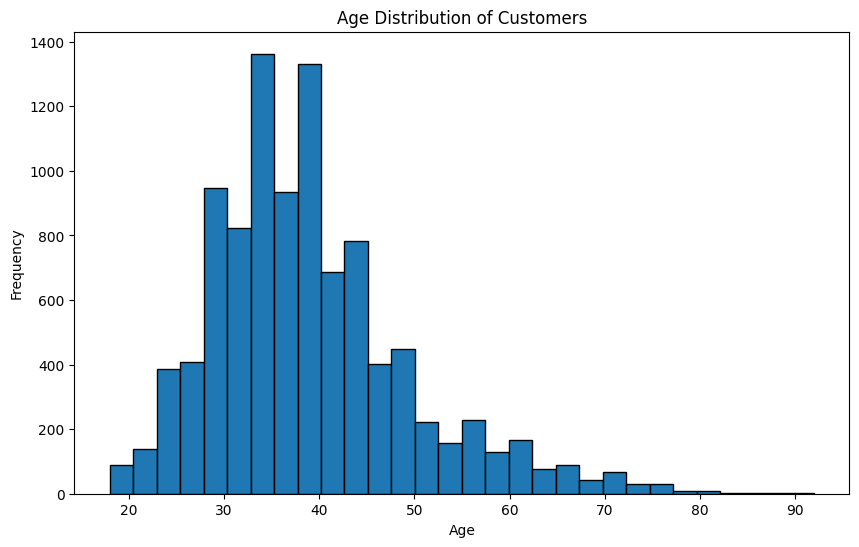

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, edgecolor='k')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

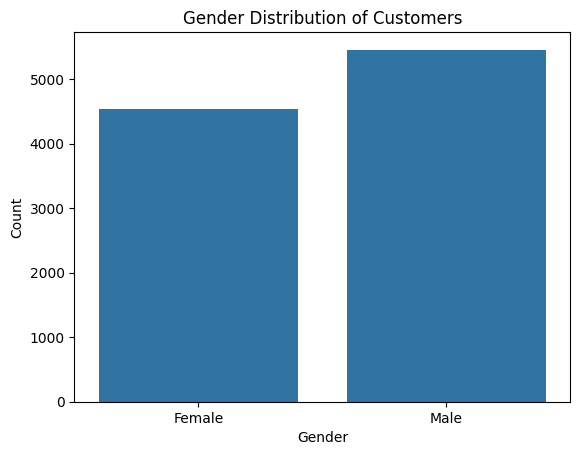

In [23]:
plt.Figure(figsize=(10, 6))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

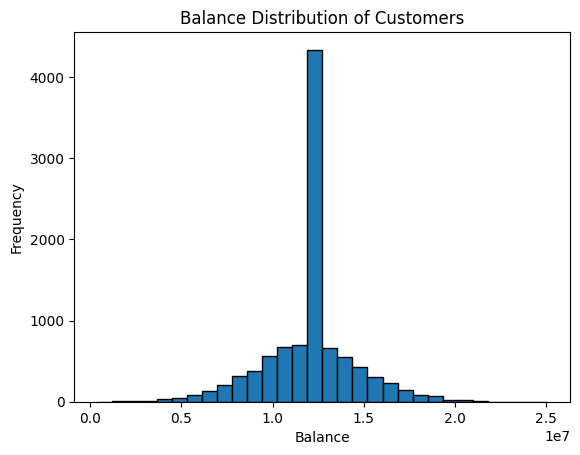

In [24]:
plt.Figure(figsize=(10, 6))
plt.hist(df[['Balance']], bins=30, edgecolor='k')
plt.title('Balance Distribution of Customers')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()